### Trading using the Black-Scholes Model


#### Solving the Black-Scholes Equation Yields
$$C = S_t \Phi(d_1) - Ke^{-rt} \Phi(d_2)$$

$$\Phi(x) = \int_{-\infty}^x \frac{1}{\sqrt{2\pi}}e^{\frac{-s^2}{2}}ds$$

$$d_1 = \frac{ln(\frac{S_t}{K})+(r+\frac{\sigma^2}{2})t}{\sigma \sqrt{t}}$$

$$d_2 = d_1 - \sigma \sqrt{t}$$

$$\frac{dS_t}{S_t} = \mu dt + \sigma dW_t$$

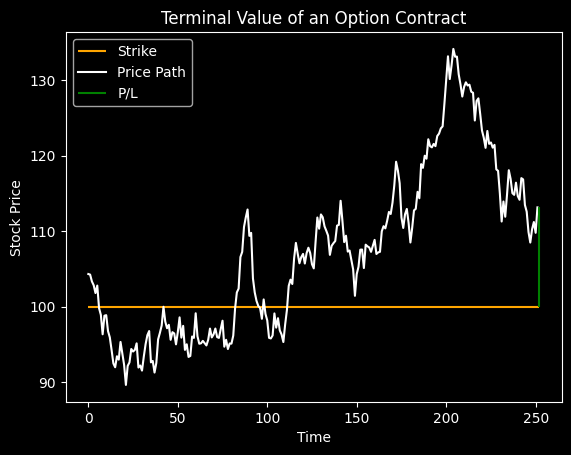

Premium at t=0: 14.231254785985819
P/L: -1.06870638228623


In [ ]:
import numpy as np
from scipy.stats import norm

def black_scholes_call(S, K, sigma, r, t):
    d1 = (np.log(S/K) + (r + ((sigma**2)/2))*t) / (sigma * np.sqrt(t))
    d2 = d1 - (sigma * np.sqrt(t))
    C = S * norm.cdf(d1) - K * np.exp(-r*t) * norm.cdf(d2)
    return C

black_scholes_call(100, 100, .3, .05, 1)


import matplotlib.pyplot as plt
import qfin as qf

# simulate dynamics of the underlying according to Geometric Brownian Motion
path = qf.simulations.GeometricBrownianMotion(100, 0.05, .3, 1/252, 1)


# create a chart of the price path and the strike price
plt.title("Terminal Value of an Option Contract")
plt.hlines(100, 0, 252, label='Strike', color='orange')
plt.plot(path.simulated_path, label='Price Path', color='white')
if max(path.simulated_path[-1] - 100, 0) == 0:
    plt.vlines(252, path.simulated_path[-1], 100, color='red', label="P/L")
else:
    plt.vlines(252, 100, path.simulated_path[-1], color='green', label="P/L")
plt.style.use('dark_background')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

# print the premium and the resulting P/L
print("Premium at t=0:", black_scholes_call(100, 100, .3, .05, 1))
print("P/L:", max(path.simulated_path[-1] - 100, 0) - black_scholes_call(100, 100, .3, .05, 1))
print("Call Price:", black_scholes_call(100, 100, .3, .05, 1))
print("Market Maker Quote:", "13.43 @ 14.10")
print("Trade Edge:", black_scholes_call(100, 100, .3, .05, 1) - 14.10)
premium = 14.10 * 100
pls = []

for i in range(100000):
    path = qf.simulations.GeometricBrownianMotion(100, 0.05, .3, 1/252, 1)
    pls.append(max(path.simulated_path[-1] - 100, 0)*100 - premium)

np.mean(pls)

premium = 14.10 * 100
pls = []

for i in range(100000):
    path = qf.simulations.GeometricBrownianMotion(100, -.5, .3, 1/252, 1)
    pls.append(max(path.simulated_path[-1] - 100, 0)*100 - premium)

plt.title("Trading this Edge Over Time")
plt.plot(np.cumsum(pls), label="Account Equity")
plt.style.use('dark_background')
plt.xlabel('Option Trade')
plt.ylabel('Portfolio Value')
plt.legend()
plt.show()

In [ ]:
import math
import time
import requests
import numpy as np
from dataclasses import dataclass
from typing import List, Dict, Optional
from scipy.stats import norm

FMP_API_KEY = "YOUR_FMP_KEY"  # TODO: buraya kendi anahtarını koy

# ========= 1) Black–Scholes & Greeks & Implied Vol =========

def black_scholes_call(S: float, K: float, sigma: float, r: float, T: float) -> float:
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return float("nan")
    d1 = (np.log(S / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)

def greeks_call(S, K, sigma, r, T):
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return {"delta": np.nan, "gamma": np.nan, "vega": np.nan, "theta": np.nan}
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega  = S * norm.pdf(d1) * np.sqrt(T)  # per 1.0 vola (not %)
    theta = (- (S * norm.pdf(d1) * sigma) / (2*np.sqrt(T))
             - r * K * math.exp(-r*T) * norm.cdf(d2))
    return {"delta": delta, "gamma": gamma, "vega": vega, "theta": theta}

def implied_vol_call(mkt_price, S, K, r, T, tol=1e-6, max_iter=100):
    # Brent benzeri basit arama (alt/üst)
    if mkt_price <= max(S - K * math.exp(-r*T), 0):
        return 0.0
    low, high = 1e-6, 5.0
    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        price = black_scholes_call(S, K, mid, r, T)
        if abs(price - mkt_price) < tol:
            return mid
        if price > mkt_price:
            high = mid
        else:
            low = mid
    return 0.5 * (low + high)

# ========= 2) FMP Client =========

BASE = "https://financialmodelingprep.com/api/v3"

def _get(endpoint: str, params: Dict=None):
    if params is None: params = {}
    params["apikey"] = FMP_API_KEY
    url = f"{BASE}/{endpoint}"
    r = requests.get(url, params=params, timeout=20)
    r.raise_for_status()
    return r.json()

def get_sp500_symbols() -> List[str]:
    # S&P 500 constituent list
    data = _get("sp500_constituent")
    # FMP genelde: [{"symbol":"AAPL","name":"Apple Inc."}, ...]
    return [row["symbol"] for row in data if "symbol" in row]

def get_quote(symbol: str) -> Optional[dict]:
    q = _get(f"quote/{symbol}")
    return q[0] if isinstance(q, list) and q else None

def get_treasury_yield(days=30) -> float:
    # Basit yaklaşım: 1M UST’yi risksiz oran proxysi olarak kullan (yıllık %)
    # Alternatif: risk-free’yi vade-uyumlu seç (T’ye göre 1M/3M/6M/1Y)
    t = _get("treasury", {"from": "", "to": ""})
    # t: [{"date":"2025-10-21","month1":0.0,"month3":...}, ...] olabilir.
    # Emniyetli çekim:
    if isinstance(t, list) and t:
        last = t[0]
        # Eğer "month1" yoksa "year1"/"month3" vb. fallback
        for key in ["month1","month3","month6","year1"]:
            if key in last and last[key] is not None:
                return float(last[key]) / 100.0
    # fallback sabit
    return 0.03

def get_option_chain(symbol: str) -> List[dict]:
    # FMP’de opsiyon zinciri:
    # /api/v3/options/symbol/{symbol}?&apikey=...
    # veya /api/v3/options-chain/{symbol}?startDate=YYYY-MM-DD&endDate=...
    try:
        chain = _get(f"options/symbol/{symbol}")
        return chain if isinstance(chain, list) else []
    except Exception:
        return []

# ========= 3) Screener (Underpriced Calls) =========

@dataclass
class OptionRow:
    symbol: str
    expiration: str
    side: str
    strike: float
    last_price: float
    bid: float
    ask: float
    open_interest: int
    iv: Optional[float]
    T: float
    edge_pct: float
    bs_price: float
    greeks: dict

def days_to_years(dte_days: int) -> float:
    return max(dte_days, 1) / 365.0

def choose_target_contracts(chain: List[dict], min_dte=25, max_dte=70, near_money_ratio=0.1):
    """
    near_money_ratio=0.1 → spot +/- %10 bandındaki strike'lar
    """
    groups = {}
    for row in chain:
        # row yapısı FMP varyantına göre değişebilir
        typ = str(row.get("type","")).lower()
        if typ != "call": 
            continue
        exp = row.get("expirationDate") or row.get("expiration") or row.get("expiryDate")
        if not exp: 
            continue
        # DTE tahmini (FMP bazen 'daysToExpiration' verir)
        dte = row.get("daysToExpiration")
        if dte is None:
            # kaba tahmin yoksa bu sözleşmeyi atlayabiliriz
            continue
        if not (min_dte <= dte <= max_dte):
            continue
        groups.setdefault(exp, []).append(row)
    return groups

def screen_underpriced_calls(symbols: List[str],
                             min_dte=25, max_dte=70,
                             near_money=0.1,
                             max_per_symbol=3,
                             use_market_iv_first=True,
                             spread_limit=0.15,
                             top_k=15):
    rf = get_treasury_yield()
    results: List[OptionRow] = []
    for i, sym in enumerate(symbols, 1):
        try:
            q = get_quote(sym)
            if not q: 
                continue
            S = float(q.get("price") or q.get("previousClose") or 0)
            if S <= 1: 
                continue

            chain = get_option_chain(sym)
            if not chain: 
                continue

            groups = choose_target_contracts(chain, min_dte, max_dte, near_money)
            picks = 0

            for exp, rows in groups.items():
                # near-ATM filtre
                near = [r for r in rows if abs(float(r.get("strike",0)) - S) / S <= near_money]
                # likidite -> spread filtresi
                filtered = []
                for r in near:
                    bid = float(r.get("bid", 0) or 0)
                    ask = float(r.get("ask", 0) or 0)
                    last = float(r.get("lastPrice", 0) or 0)
                    if ask <= 0 or bid < 0:
                        continue
                    spread = (ask - bid) / ask if ask > 0 else 1.0
                    if spread_limit is not None and spread > spread_limit:
                        continue
                    filtered.append(r)
                # edge hesapla
                for r in filtered:
                    K = float(r["strike"])
                    dte = int(r.get("daysToExpiration", 30))
                    T = days_to_years(dte)
                    mkt = float(r.get("mid", (r.get("bid",0)+r.get("ask",0))/2) or 0)
                    if mkt <= 0: 
                        continue

                    # volatilite seçimi
                    iv_val = None
                    if use_market_iv_first:
                        iv_raw = r.get("impliedVolatility")
                        if iv_raw not in (None, 0, "0", ""):
                            try:
                                iv_val = float(iv_raw)
                                if iv_val > 2.0:  # FMP bazen % cinsinden gelebilir
                                    iv_val = iv_val/100.0
                            except:
                                iv_val = None

                    if iv_val is None:
                        # fallback: implied vol’u mkt fiyattan çöz
                        iv_val = implied_vol_call(mkt, S, K, rf, T)
                        if iv_val <= 0:
                            continue

                    bs_p = black_scholes_call(S, K, iv_val, rf, T)
                    if bs_p <= 0:
                        continue
                    edge = (mkt - bs_p) / bs_p

                    grek = greeks_call(S, K, iv_val, rf, T)
                    row = OptionRow(
                        symbol=sym,
                        expiration=exp,
                        side="CALL",
                        strike=K,
                        last_price=float(r.get("lastPrice", 0) or 0),
                        bid=float(r.get("bid", 0) or 0),
                        ask=float(r.get("ask", 0) or 0),
                        open_interest=int(r.get("openInterest", 0) or 0),
                        iv=iv_val,
                        T=T,
                        edge_pct=edge,
                        bs_price=bs_p,
                        greeks=grek
                    )
                    results.append(row)
                    picks += 1
                    if picks >= max_per_symbol:
                        break

            # nazik rate-limit
            if i % 10 == 0:
                time.sleep(0.8)

        except Exception as e:
            # sembol bazında hatayı atla
            continue

    # “ucuz” arıyoruz → mkt < BS ise edge negatif olur; en düşük edge en cazip
    results.sort(key=lambda x: x.edge_pct)
    return results[:top_k]

# ========= 4) Çalıştır: Top 10 “underpriced” CALL =========

if __name__ == "__main__":
    syms = get_sp500_symbols()
    # hızlı demo için sınırlayalım:
    universe = syms[:80]  # ilk 80 sembol
    top = screen_underpriced_calls(universe,
                                   min_dte=25, max_dte=70,
                                   near_money=0.08,
                                   max_per_symbol=2,
                                   spread_limit=0.20,
                                   top_k=10)
    print("\n=== TOP UNDERPRICED CALL CANDIDATES (30–60 DTE civarı) ===")
    for r in top:
        print(f"{r.symbol:6s}  {r.expiration}  K={r.strike:>7.2f}  IV={r.iv:5.3f}  "
              f"mkt≈{(r.bid+r.ask)/2:>7.2f}  BS={r.bs_price:>7.2f}  edge={100*r.edge_pct:>6.2f}%  "
              f"OI={r.open_interest:>6d}  Δ={r.greeks['delta']:.3f}")
